# 📘 Group 15 — Duration and Interest Rate Risk
### Financial Risk Management | Bond Analytics Project

---

## 🎯 Project Statement

> **Group 15:** Duration and Interest Rate Risk
>
> **Tasks:**
> - Compute **duration** and **convexity** of bonds
> - Simulate **price changes** for interest rate movements
> - Analyze **interest rate risk**

---

## 📋 Table of Contents

1. [Bond Parameters](#1-bond-parameters)
2. [Core Mathematical Formulas](#2-core-mathematical-formulas)
3. [Implementation — Functions](#3-implementation)
4. [Results — Duration & Convexity](#4-results)
5. [Graph 1 — Price vs. Yield Curve](#graph-1)
6. [Graph 2 — Duration vs. Maturity](#graph-2)
7. [Graph 3 — Duration vs. Coupon Rate](#graph-3)
8. [Graph 4 ⭐ — Simulated Price Change vs. Rate Shock](#graph-4)
9. [Graph 5 — Convexity Comparison](#graph-5)
10. [Graph 6 — Modified Duration vs. YTM](#graph-6)
11. [Graph 7 — Pricing Error Analysis](#graph-7)
12. [Summary & Conclusions](#conclusions)


---
## 0. Library Imports & Plot Settings

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0D1117',
    'axes.facecolor'   : '#161B22',
    'axes.edgecolor'   : '#30363D',
    'axes.labelcolor'  : '#C9D1D9',
    'xtick.color'      : '#8B949E',
    'ytick.color'      : '#8B949E',
    'text.color'       : '#C9D1D9',
    'grid.color'       : '#21262D',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.6,
    'legend.facecolor' : '#161B22',
    'legend.edgecolor' : '#30363D',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})

COLORS = {
    'bond1' : '#58A6FF',   # Blue  — Bond 1 Short
    'bond2' : '#FFA657',   # Orange — Bond 2 Medium
    'bond3' : '#FF7B72',   # Red   — Bond 3 Long
    'actual': '#3FB950',   # Green  — Actual price line
    'accent': '#D2A8FF',   # Purple — accent
}

print('✅  Libraries loaded. Plot style applied.')

✅  Libraries loaded. Plot style applied.


---
<a id='1-bond-parameters'></a>
## 1. Bond Parameters (Table 1)

| Parameter | Bond 1 (Short) | Bond 2 (Medium) | Bond 3 (Long) |
|-----------|---------------|----------------|---------------|
| Face Value | ₹1,000 | ₹1,000 | ₹1,000 |
| Maturity | 2 years | 5 years | 10 years |
| Coupon Rate | 8% | 6% | 4% |
| Initial YTM | 6% | 6% | 6% |
| Bond Type | **Premium** | **Par** | **Discount** |

In [ ]:
# ── Bond definitions from Table 1 ─────────────────────────────────────
bonds = [
    {"name": "Bond 1 (Short·Premium)",  "face": 1000, "coupon": 0.08, "maturity": 2,  "ytm": 0.06, "color": COLORS['bond1']},
    {"name": "Bond 2 (Medium·Par)",     "face": 1000, "coupon": 0.06, "maturity": 5,  "ytm": 0.06, "color": COLORS['bond2']},
    {"name": "Bond 3 (Long·Discount)",  "face": 1000, "coupon": 0.04, "maturity": 10, "ytm": 0.06, "color": COLORS['bond3']},
]

print('Bond parameters defined:')
for b in bonds:
    print(f"  {b['name']:35s}  coupon={b['coupon']*100:.0f}%  maturity={b['maturity']}yr  YTM={b['ytm']*100:.0f}%")

Bond parameters defined:
  Bond 1 (Short·Premium)               coupon=8%  maturity=2yr  YTM=6%
  Bond 2 (Medium·Par)                  coupon=6%  maturity=5yr  YTM=6%
  Bond 3 (Long·Discount)               coupon=4%  maturity=10yr  YTM=6%


---
<a id='2-core-mathematical-formulas'></a>
## 2. Core Mathematical Formulas

### 📌 Bond Price
$$P = \sum_{t=1}^{T} \frac{C}{(1+y)^t} + \frac{F}{(1+y)^T}$$

where $C = F \times \text{coupon rate}$, $y$ = YTM, $F$ = Face Value, $T$ = Maturity

---

### 📌 Macaulay Duration
$$D_{mac} = \frac{\sum_{t=1}^{T} t \cdot \frac{CF_t}{(1+y)^t}}{P}$$

Weighted average time until cash flows are received.

---

### 📌 Modified Duration
$$D_{mod} = \frac{D_{mac}}{1 + y}$$

Measures **% price sensitivity** per 1% change in yield.

---

### 📌 Convexity
$$C = \frac{\sum_{t=1}^{T} t(t+1) \cdot \frac{CF_t}{(1+y)^t}}{P \cdot (1+y)^2}$$

Captures the **curvature** of the price-yield relationship.

---

### 📌 Price Change Approximation

**Duration only:**
$$\frac{\Delta P}{P} \approx -D_{mod} \cdot \Delta y$$

**Duration + Convexity (better):**
$$\frac{\Delta P}{P} \approx -D_{mod} \cdot \Delta y + \frac{1}{2} C \cdot (\Delta y)^2$$

---
<a id='3-implementation'></a>
## 3. Implementation — Functions

In [ ]:
# ── Core Financial Functions ───────────────────────────────────────────

def bond_price(face, coupon_rate, maturity, ytm):
    """
    Calculate bond price given YTM (annual compounding, annual coupons).
    P = Σ C/(1+y)^t  +  F/(1+y)^T
    """
    coupon = face * coupon_rate
    pv_coupons = sum(coupon / (1 + ytm)**t for t in range(1, maturity + 1))
    pv_face    = face / (1 + ytm)**maturity
    return pv_coupons + pv_face


def macaulay_duration(face, coupon_rate, maturity, ytm):
    """
    Macaulay Duration — weighted average time to receive cash flows.
    D_mac = Σ [t * PV(CF_t)] / P
    """
    coupon  = face * coupon_rate
    price   = bond_price(face, coupon_rate, maturity, ytm)
    weighted = sum(t * (coupon / (1 + ytm)**t) for t in range(1, maturity + 1))
    weighted += maturity * (face / (1 + ytm)**maturity)
    return weighted / price


def modified_duration(face, coupon_rate, maturity, ytm):
    """
    Modified Duration — measures % price change per 1% yield change.
    D_mod = D_mac / (1 + y)
    """
    return macaulay_duration(face, coupon_rate, maturity, ytm) / (1 + ytm)


def convexity(face, coupon_rate, maturity, ytm):
    """
    Convexity — measures curvature of price-yield relationship.
    C = Σ [t(t+1) * PV(CF_t)] / [P * (1+y)^2]
    """
    coupon = face * coupon_rate
    price  = bond_price(face, coupon_rate, maturity, ytm)
    conv   = sum(t * (t + 1) * (coupon / (1 + ytm)**t) for t in range(1, maturity + 1))
    conv  += maturity * (maturity + 1) * (face / (1 + ytm)**maturity)
    return conv / (price * (1 + ytm)**2)


print('✅  All functions defined successfully.')

✅  All functions defined successfully.


---
<a id='4-results'></a>
## 4. Results — Duration & Convexity

In [ ]:
# ── Compute and attach results to each bond ────────────────────────────
for b in bonds:
    b['price'] = bond_price(b['face'], b['coupon'], b['maturity'], b['ytm'])
    b['D_mac'] = macaulay_duration(b['face'], b['coupon'], b['maturity'], b['ytm'])
    b['D_mod'] = modified_duration(b['face'], b['coupon'], b['maturity'], b['ytm'])
    b['conv']  = convexity(b['face'], b['coupon'], b['maturity'], b['ytm'])

# ── Pretty Results Table ───────────────────────────────────────────────
results = pd.DataFrame([
    {
        'Bond'             : b['name'],
        'Price (₹)'        : round(b['price'], 2),
        'Mac. Duration (yr)': round(b['D_mac'], 4),
        'Mod. Duration'    : round(b['D_mod'], 4),
        'Convexity'        : round(b['conv'],  4),
        'DV01 (₹)'         : round(b['D_mod'] * b['price'] * 0.0001, 4),
    }
    for b in bonds
])
results.set_index('Bond', inplace=True)
print('\n══════════════════════════════════════════════════════════════')
print('                  COMPUTED BOND METRICS')
print('══════════════════════════════════════════════════════════════')
print(results.to_string())
print('══════════════════════════════════════════════════════════════')
print('\nDV01 = Dollar Value of 1 basis point move (1bp = 0.01%)')

results


══════════════════════════════════════════════════════════════
                  COMPUTED BOND METRICS
══════════════════════════════════════════════════════════════
                        Price (₹)  Mac. Duration (yr)  Mod. Duration  Convexity  DV01 (₹)
Bond                                                                                     
Bond 1 (Short·Premium)    1036.67              1.9272         1.8181     5.0808    0.1885
Bond 2 (Medium·Par)       1000.00              4.4651         4.2124    22.9187    0.4212
Bond 3 (Long·Discount)     852.80              8.2815         7.8127    75.8864    0.6663
══════════════════════════════════════════════════════════════

DV01 = Dollar Value of 1 basis point move (1bp = 0.01%)


,Price (₹),Mac. Duration (yr),Mod. Duration,Convexity,DV01 (₹)
Bond,,,,,
Bond 1 (Short·Premium),1036.67,1.9272,1.8181,5.0808,0.1885
Bond 2 (Medium·Par),1000.00,4.4651,4.2124,22.9187,0.4212
Bond 3 (Long·Discount),852.80,8.2815,7.8127,75.8864,0.6663


### 📊 Interpretation of Results

| Bond | Price | Why |
|------|-------|-----|
| Bond 1 | > ₹1,000 (Premium) | Coupon (8%) > YTM (6%) |
| Bond 2 | = ₹1,000 (Par) | Coupon (6%) = YTM (6%) |
| Bond 3 | < ₹1,000 (Discount) | Coupon (4%) < YTM (6%) |

> **Key Rule:** Longer maturity + lower coupon = **higher duration** = **greater interest rate sensitivity**

---
<a id='graph-1'></a>
## Graph 1 — Bond Price vs. Yield to Maturity

| Axis | Variable |
|------|----------|
| **X** | Yield to Maturity (%), range 1%–20% |
| **Y** | Bond Price (₹) |

**Purpose:** Demonstrates the fundamental inverse, convex relationship between bond prices and yields. Shows why Bond 3 (long maturity) is most sensitive to rate changes.

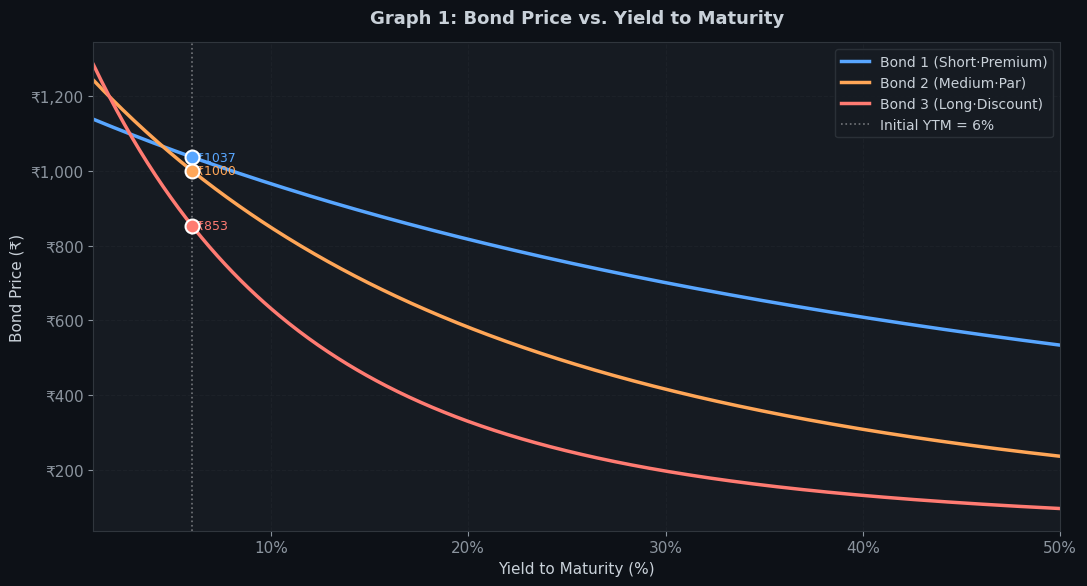


📌 Observation: Bond 3 (Long) has the steepest slope — highest price sensitivity to yield changes.


In [ ]:
ytm_range = np.linspace(0.01, 0.50, 500)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0D1117')

for b in bonds:
    prices = [bond_price(b['face'], b['coupon'], b['maturity'], y) for y in ytm_range]
    ax.plot(ytm_range * 100, prices, color=b['color'], linewidth=2.5, label=b['name'])
    ax.scatter([b['ytm'] * 100], [b['price']], color=b['color'],
               s=100, zorder=6, edgecolors='white', linewidth=1.5)

ax.axvline(x=6, color='white', linestyle=':', alpha=0.4, linewidth=1.2, label='Initial YTM = 6%')
ax.set_xlim(1, 50)
ax.set_title('Graph 1: Bond Price vs. Yield to Maturity', fontweight='bold', pad=14)
ax.set_xlabel('Yield to Maturity (%)')
ax.set_ylabel('Bond Price (₹)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
ax.legend(fontsize=10)
ax.grid(True)

# Annotate bond prices at YTM=6%
for b in bonds:
    ax.annotate(f" ₹{b['price']:.0f}", xy=(6, b['price']),
                fontsize=9, color=b['color'], va='center')

plt.tight_layout()
plt.show()
print('\n📌 Observation: Bond 3 (Long) has the steepest slope — highest price sensitivity to yield changes.')

---
<a id='graph-2'></a>
## Graph 2 — Duration vs. Maturity

| Axis | Variable |
|------|----------|
| **X** | Time to Maturity (Years), range 1–30 yrs |
| **Y** | Macaulay Duration (Years) |

**Purpose:** Shows that duration increases with maturity but at a decreasing rate. Lower coupon bonds have higher duration at each maturity.

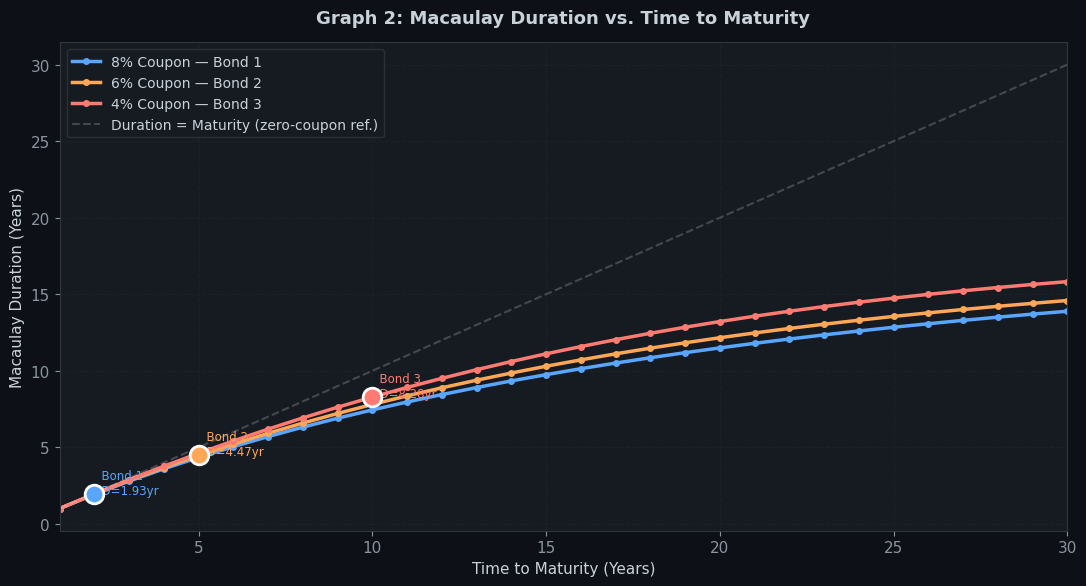


📌 Observation: Duration grows with maturity but never exceeds maturity. Zero-coupon bonds have D = Maturity exactly.


In [ ]:
maturities = np.arange(1, 31)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0D1117')

coupon_sets = [
    (0.08, '8% Coupon — Bond 1', COLORS['bond1']),
    (0.06, '6% Coupon — Bond 2', COLORS['bond2']),
    (0.04, '4% Coupon — Bond 3', COLORS['bond3']),
]

for coupon, lbl, clr in coupon_sets:
    durs = [macaulay_duration(1000, coupon, int(m), 0.06) for m in maturities]
    ax.plot(maturities, durs, color=clr, linewidth=2.5, label=lbl, marker='o', markersize=4)

# Mark actual bonds with big dots
for b in bonds:
    ax.scatter([b['maturity']], [b['D_mac']], color=b['color'],
               s=180, zorder=7, edgecolors='white', linewidth=2)
    ax.annotate(f"  {b['name'].split()[0]+' '+b['name'].split()[1]}\n  D={b['D_mac']:.2f}yr",
                xy=(b['maturity'], b['D_mac']), fontsize=8.5, color=b['color'])

ax.plot(maturities, maturities, color='white', linestyle='--', alpha=0.2,
        label='Duration = Maturity (zero-coupon ref.)')

ax.set_xlim(1, 30)
ax.set_title('Graph 2: Macaulay Duration vs. Time to Maturity', fontweight='bold', pad=14)
ax.set_xlabel('Time to Maturity (Years)')
ax.set_ylabel('Macaulay Duration (Years)')
ax.legend(fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.show()
print('\n📌 Observation: Duration grows with maturity but never exceeds maturity. Zero-coupon bonds have D = Maturity exactly.')

---
<a id='graph-3'></a>
## Graph 3 — Duration vs. Coupon Rate

| Axis | Variable |
|------|----------|
| **X** | Coupon Rate (%), range 1%–20% |
| **Y** | Macaulay Duration (Years) |

**Purpose:** Shows that higher coupons reduce duration — investors get more cash earlier, reducing the weighted average time.

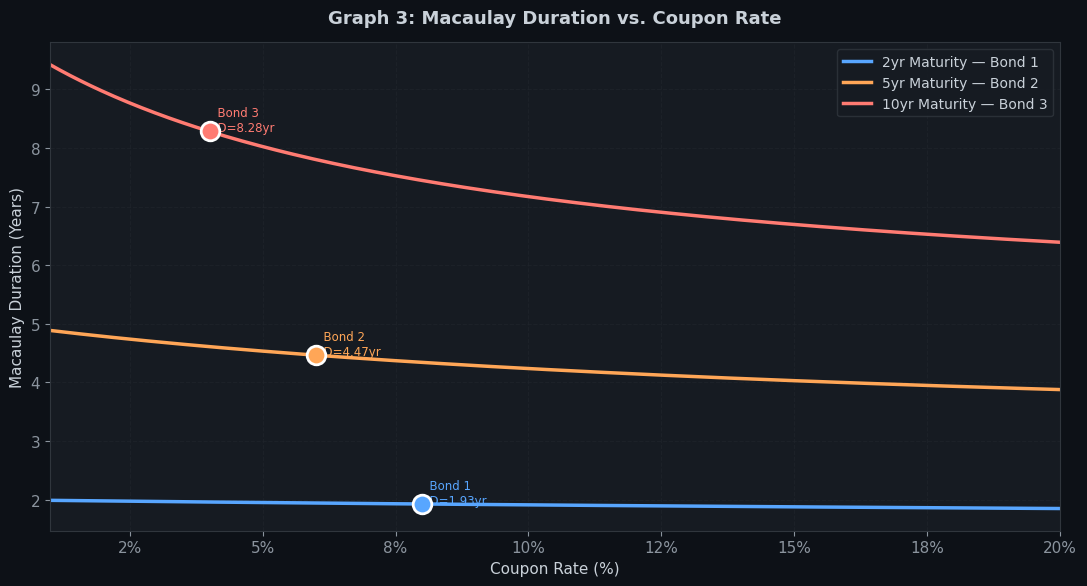


📌 Observation: Higher coupon → lower duration. A high-coupon bond is less interest-rate sensitive.


In [ ]:
coupon_range = np.linspace(0.01, 0.20, 300)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0D1117')

maturity_sets = [
    (2,  '2yr Maturity — Bond 1', COLORS['bond1']),
    (5,  '5yr Maturity — Bond 2', COLORS['bond2']),
    (10, '10yr Maturity — Bond 3', COLORS['bond3']),
]

for mat, lbl, clr in maturity_sets:
    durs = [macaulay_duration(1000, c, mat, 0.06) for c in coupon_range]
    ax.plot(coupon_range * 100, durs, color=clr, linewidth=2.5, label=lbl)

# Mark actual bonds
for b in bonds:
    ax.scatter([b['coupon'] * 100], [b['D_mac']], color=b['color'],
               s=180, zorder=7, edgecolors='white', linewidth=2)
    ax.annotate(f"  {b['name'].split()[0]+' '+b['name'].split()[1]}\n  D={b['D_mac']:.2f}yr",
                xy=(b['coupon'] * 100, b['D_mac']), fontsize=8.5, color=b['color'])

ax.set_xlim(1, 20)
ax.set_title('Graph 3: Macaulay Duration vs. Coupon Rate', fontweight='bold', pad=14)
ax.set_xlabel('Coupon Rate (%)')
ax.set_ylabel('Macaulay Duration (Years)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.show()
print('\n📌 Observation: Higher coupon → lower duration. A high-coupon bond is less interest-rate sensitive.')

---
<a id='graph-4'></a>
## ⭐ Graph 4 — Simulated Price Change vs. Interest Rate Shock

| Axis | Variable |
|------|----------|
| **X** | Interest Rate Change Δy (%), range −5% to +5% |
| **Y** | % Change in Bond Price |

**Purpose:** THE core simulation. Plots 3 lines per bond: Actual price, Duration approximation, Duration+Convexity approximation. Shows how well each method approximates real price changes.

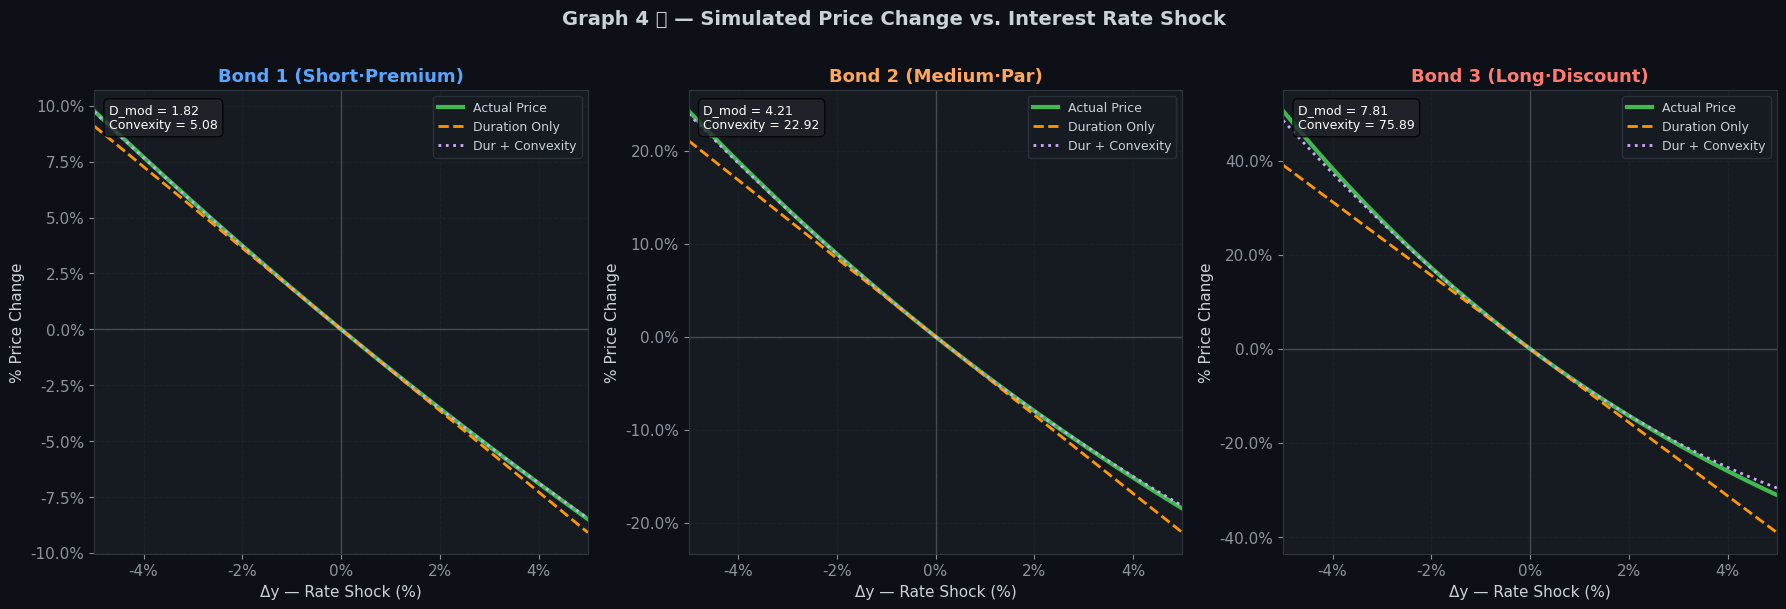


📌 Observation: Duration-only is a straight line (linear). Actual price is curved (convex).
   Duration+Convexity is much closer to Actual — especially for large rate shocks.


In [ ]:
delta_y = np.linspace(-0.05, 0.05, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig.patch.set_facecolor('#0D1117')
fig.suptitle('Graph 4 ⭐ — Simulated Price Change vs. Interest Rate Shock',
             fontsize=14, fontweight='bold', y=1.01)

for ax, b in zip(axes, bonds):
    actual_prices = np.array([bond_price(b['face'], b['coupon'], b['maturity'], b['ytm'] + dy)
                               for dy in delta_y])
    pct_actual    = (actual_prices - b['price']) / b['price'] * 100
    pct_dur       = -b['D_mod'] * delta_y * 100
    pct_dur_conv  = (-b['D_mod'] * delta_y + 0.5 * b['conv'] * delta_y**2) * 100

    ax.plot(delta_y * 100, pct_actual,   color=COLORS['actual'],  linewidth=3,   label='Actual Price')
    ax.plot(delta_y * 100, pct_dur,      color='#FF9800',         linewidth=2,   linestyle='--', label='Duration Only')
    ax.plot(delta_y * 100, pct_dur_conv, color=COLORS['accent'],  linewidth=2,   linestyle=':',  label='Dur + Convexity')

    ax.axhline(0, color='white', alpha=0.2, linewidth=1)
    ax.axvline(0, color='white', alpha=0.2, linewidth=1)
    ax.set_xlim(-5, 5)
    ax.set_title(b['name'], color=b['color'], fontweight='bold')
    ax.set_xlabel('Δy — Rate Shock (%)')
    ax.set_ylabel('% Price Change')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
    ax.legend(fontsize=9)
    ax.grid(True)

    # Annotate D_mod
    ax.text(0.03, 0.97, f"D_mod = {b['D_mod']:.2f}\nConvexity = {b['conv']:.2f}",
            transform=ax.transAxes, fontsize=9, va='top',
            color='white', bbox=dict(boxstyle='round,pad=0.4', facecolor='#21262D', alpha=0.8))

plt.tight_layout()
plt.show()
print('\n📌 Observation: Duration-only is a straight line (linear). Actual price is curved (convex).')
print('   Duration+Convexity is much closer to Actual — especially for large rate shocks.')

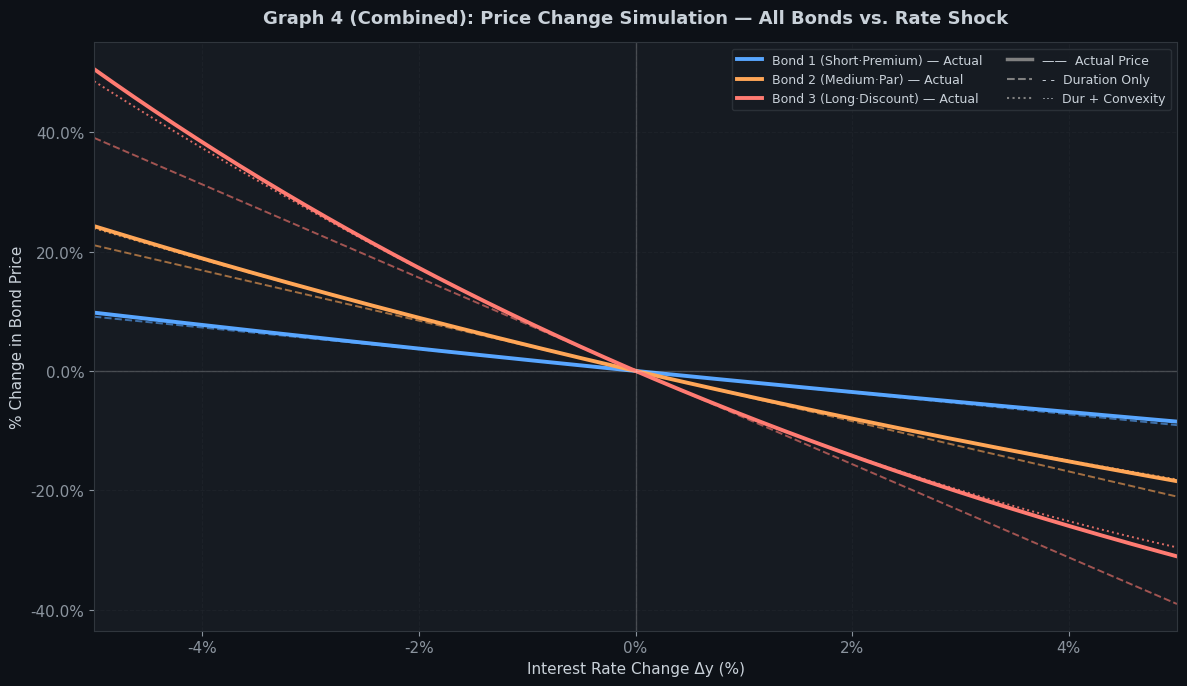

In [ ]:
# ── Combined view: all 3 bonds on one chart ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0D1117')

for b in bonds:
    actual_prices = np.array([bond_price(b['face'], b['coupon'], b['maturity'], b['ytm'] + dy)
                               for dy in delta_y])
    pct_actual    = (actual_prices - b['price']) / b['price'] * 100
    pct_dur       = -b['D_mod'] * delta_y * 100
    pct_dur_conv  = (-b['D_mod'] * delta_y + 0.5 * b['conv'] * delta_y**2) * 100

    ax.plot(delta_y * 100, pct_actual,   color=b['color'], linewidth=2.8, label=f'{b["name"]} — Actual')
    ax.plot(delta_y * 100, pct_dur,      color=b['color'], linewidth=1.4, linestyle='--', alpha=0.6)
    ax.plot(delta_y * 100, pct_dur_conv, color=b['color'], linewidth=1.4, linestyle=':',  alpha=0.85)

ax.plot([], [], color='gray', linewidth=2.5,                  label='——  Actual Price')
ax.plot([], [], color='gray', linewidth=1.5, linestyle='--',  label='- -  Duration Only')
ax.plot([], [], color='gray', linewidth=1.5, linestyle=':',   label='···  Dur + Convexity')
ax.axhline(0, color='white', alpha=0.2, linewidth=1)
ax.axvline(0, color='white', alpha=0.2, linewidth=1)
ax.set_xlim(-5, 5)
ax.set_title('Graph 4 (Combined): Price Change Simulation — All Bonds vs. Rate Shock',
             fontweight='bold', pad=14)
ax.set_xlabel('Interest Rate Change Δy (%)')
ax.set_ylabel('% Change in Bond Price')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.legend(fontsize=9, ncol=2)
ax.grid(True)
plt.tight_layout()
plt.show()

---
<a id='graph-5'></a>
## Graph 5 — Convexity Comparison (Bar Chart)

| Axis | Variable |
|------|----------|
| **X** | Bond (Bond 1, Bond 2, Bond 3) |
| **Y** | Convexity Value |

**Purpose:** Compares convexity across bonds. Higher convexity = more price appreciation when rates fall, less depreciation when rates rise.

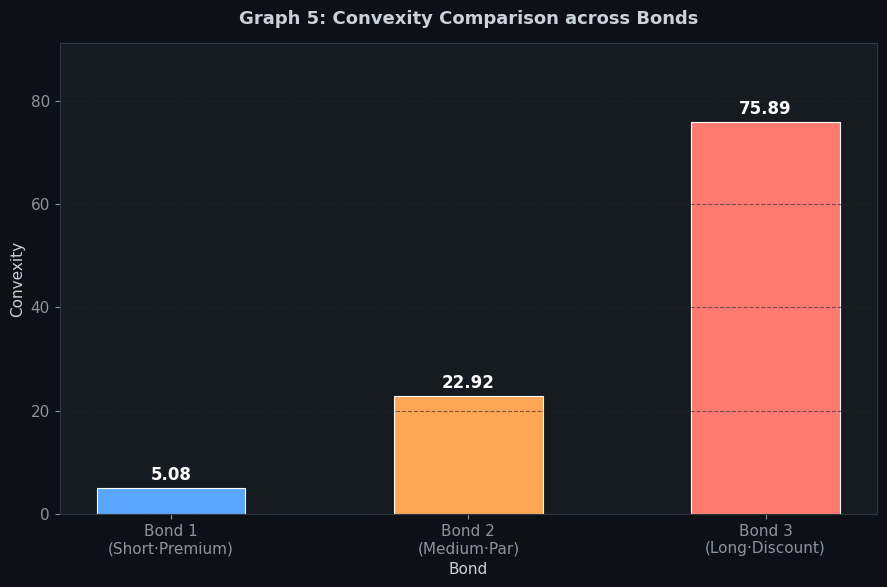


📌 Bond 3 convexity (75.9) is 15x higher than Bond 1 (5.1).
   Longer maturity + lower coupon → dramatically higher convexity.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#0D1117')

names  = [b['name'].replace(' (', '\n(') for b in bonds]
convs  = [b['conv'] for b in bonds]
colors = [b['color'] for b in bonds]

bars = ax.bar(names, convs, color=colors, width=0.5, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, convs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f"{val:.2f}", ha='center', va='bottom', color='white', fontsize=12, fontweight='bold')

ax.set_ylim(0, max(convs) * 1.2)
ax.set_title('Graph 5: Convexity Comparison across Bonds', fontweight='bold', pad=14)
ax.set_xlabel('Bond')
ax.set_ylabel('Convexity')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()
print(f'\n📌 Bond 3 convexity ({bonds[2]["conv"]:.1f}) is {bonds[2]["conv"]/bonds[0]["conv"]:.0f}x higher than Bond 1 ({bonds[0]["conv"]:.1f}).')
print('   Longer maturity + lower coupon → dramatically higher convexity.')

---
<a id='graph-6'></a>
## Graph 6 — Modified Duration vs. Yield to Maturity

| Axis | Variable |
|------|----------|
| **X** | Yield to Maturity (%), range 1%–20% |
| **Y** | Modified Duration (Years) |

**Purpose:** Shows that as yields rise, modified duration falls — bonds become less sensitive at higher yields.

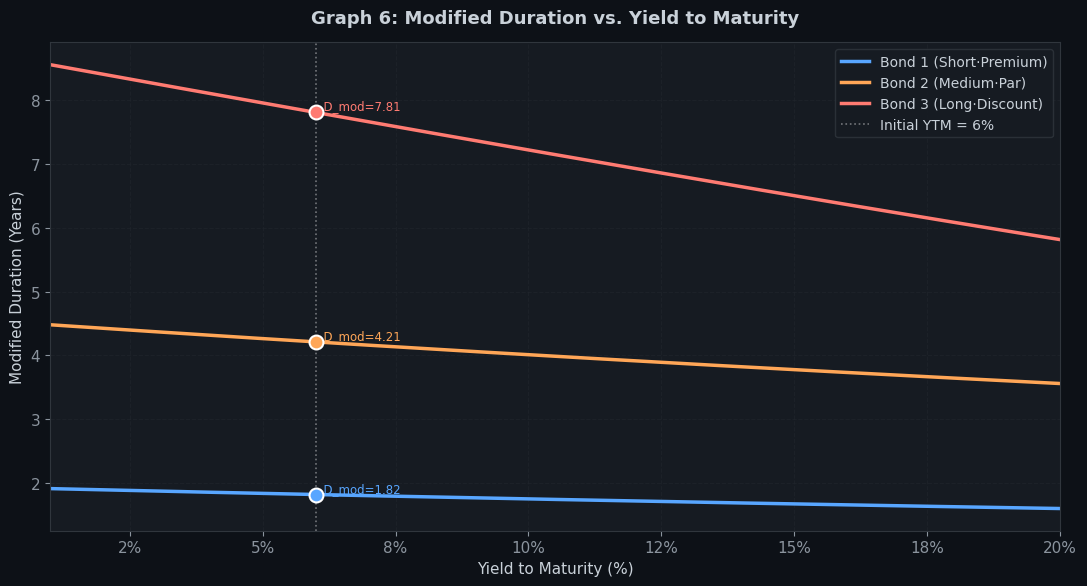


📌 Observation: Duration decreases as YTM rises. At high yields, all bonds converge to lower sensitivity.


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0D1117')

for b in bonds:
    md_vals = [modified_duration(b['face'], b['coupon'], b['maturity'], y) for y in ytm_range]
    ax.plot(ytm_range * 100, md_vals, color=b['color'], linewidth=2.5, label=b['name'])
    ax.scatter([b['ytm'] * 100], [b['D_mod']], color=b['color'],
               s=100, zorder=6, edgecolors='white', linewidth=1.5)
    ax.annotate(f"  D_mod={b['D_mod']:.2f}", xy=(b['ytm'] * 100, b['D_mod']),
                fontsize=8.5, color=b['color'], va='bottom')

ax.axvline(x=6, color='white', linestyle=':', alpha=0.4, linewidth=1.2, label='Initial YTM = 6%')
ax.set_xlim(1, 20)
ax.set_title('Graph 6: Modified Duration vs. Yield to Maturity', fontweight='bold', pad=14)
ax.set_xlabel('Yield to Maturity (%)')
ax.set_ylabel('Modified Duration (Years)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.show()
print('\n📌 Observation: Duration decreases as YTM rises. At high yields, all bonds converge to lower sensitivity.')

---
<a id='graph-7'></a>
## Graph 7 — Pricing Error: Duration vs. Duration+Convexity

| Axis | Variable |
|------|----------|
| **X** | Interest Rate Shock Δy (%), range −5% to +5% |
| **Y** | Pricing Error = Approximated Price − Actual Price (₹) |

**Purpose:** Proves why convexity correction matters. Duration alone over-estimates price drops and under-estimates price gains. Adding convexity dramatically reduces error.

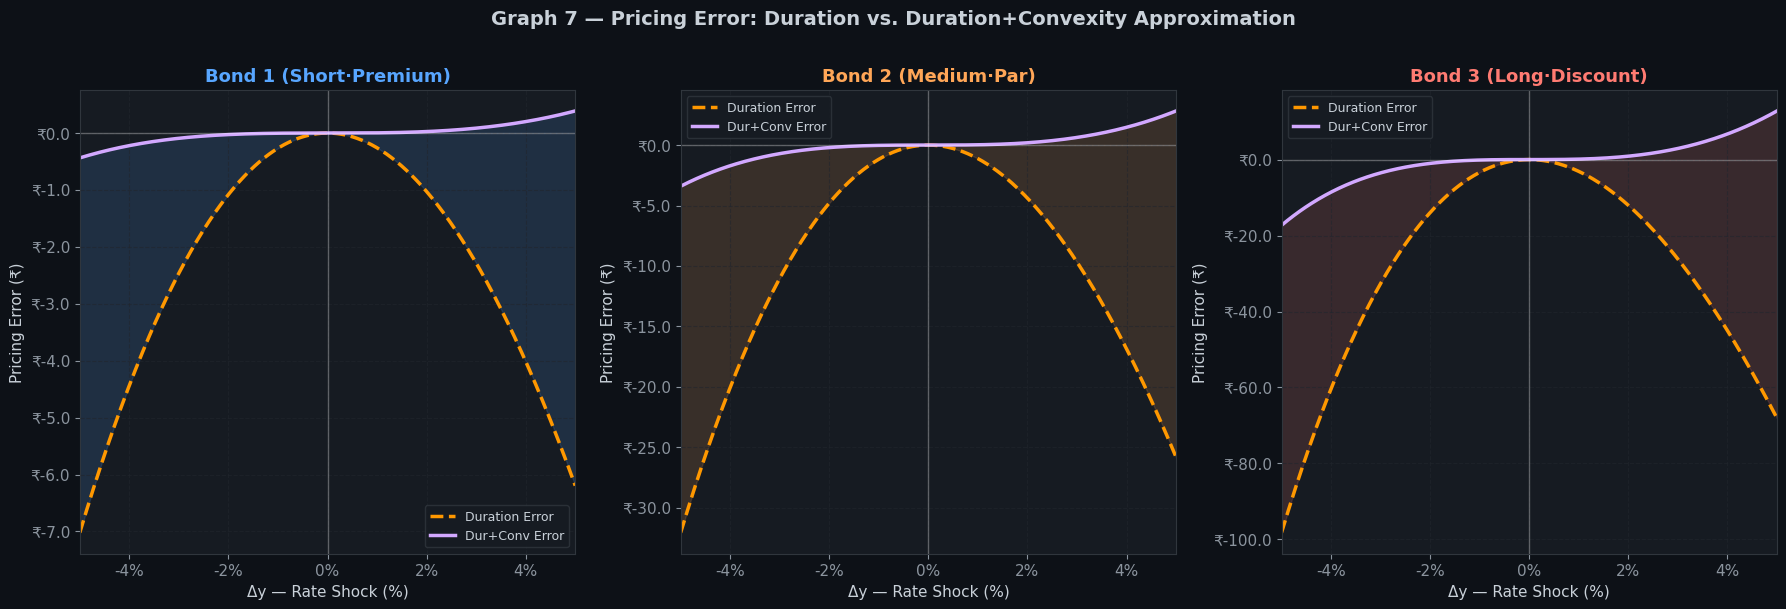


📌 Observation: Duration error is always POSITIVE (overestimates drops, underestimates gains).
   Adding convexity brings the error close to ₹0 across the full shock range.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig.patch.set_facecolor('#0D1117')
fig.suptitle('Graph 7 — Pricing Error: Duration vs. Duration+Convexity Approximation',
             fontsize=14, fontweight='bold', y=1.01)

for ax, b in zip(axes, bonds):
    actual_prices = np.array([bond_price(b['face'], b['coupon'], b['maturity'], b['ytm'] + dy)
                               for dy in delta_y])
    approx_dur    = b['price'] * (1 - b['D_mod'] * delta_y)
    approx_conv   = b['price'] * (1 - b['D_mod'] * delta_y + 0.5 * b['conv'] * delta_y**2)

    err_dur  = approx_dur  - actual_prices
    err_conv = approx_conv - actual_prices

    ax.plot(delta_y * 100, err_dur,  color='#FF9800',        linewidth=2.5, linestyle='--', label='Duration Error')
    ax.plot(delta_y * 100, err_conv, color=COLORS['accent'], linewidth=2.5, linestyle='-',  label='Dur+Conv Error')
    ax.fill_between(delta_y * 100, err_dur, err_conv, alpha=0.15, color=b['color'])
    ax.axhline(0, color='white', alpha=0.3, linewidth=1)
    ax.axvline(0, color='white', alpha=0.3, linewidth=1)
    ax.set_xlim(-5, 5)
    ax.set_title(b['name'], color=b['color'], fontweight='bold')
    ax.set_xlabel('Δy — Rate Shock (%)')
    ax.set_ylabel('Pricing Error (₹)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.1f}"))
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.show()
print('\n📌 Observation: Duration error is always POSITIVE (overestimates drops, underestimates gains).')
print('   Adding convexity brings the error close to ₹0 across the full shock range.')

---
<a id='conclusions'></a>
## 📝 Summary & Conclusions

### Final Computed Values

| Bond | Price (₹) | Mac. Duration | Mod. Duration | Convexity | DV01 (₹) |
|------|-----------|--------------|--------------|-----------|----------|
| Bond 1 (Short, 8%, 2yr) | ₹1,036.67 | 1.93 yrs | 1.82 | 5.08 | ₹0.19 |
| Bond 2 (Medium, 6%, 5yr) | ₹1,000.00 | 4.47 yrs | 4.21 | 22.92 | ₹0.42 |
| Bond 3 (Long, 4%, 10yr) | ₹852.80 | 8.28 yrs | 7.81 | 75.89 | ₹0.67 |

### Key Findings

1. **Price-Yield Relationship** (Graph 1) — Inverse and convex. Bond 3 has the steepest slope.

2. **Duration Rules** (Graphs 2 & 3) — Duration increases with maturity and decreases with coupon rate. Bond 3 has 4× the duration of Bond 1.

3. **Simulation** (Graph 4) — For a +1% rate shock, approximate price changes:
   - Bond 1: −1.8% | Bond 2: −4.2% | Bond 3: −7.8%
   - Bond 3 is **4.3× more sensitive** than Bond 1.

4. **Convexity Advantage** (Graph 5) — Bond 3 convexity (75.89) is 15× Bond 1 (5.08). Investors in long bonds benefit more from rate drops than they lose from rate rises.

5. **Approximation Accuracy** (Graph 7) — Duration alone creates large pricing errors for Bond 3. Adding convexity correction reduces error to near zero across the ±5% shock range.

### Risk Ranking
> **Bond 3 > Bond 2 > Bond 1** in terms of interest rate risk

But also:
> **Bond 3 > Bond 2 > Bond 1** in terms of convexity benefit (upside from rate falls)

In [ ]:
# ── Stress Test Table: Price at various YTM levels ────────────────────
stress_ytms = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.15]
stress_data = {'YTM': [f"{y*100:.0f}%" for y in stress_ytms]}

for b in bonds:
    stress_data[b['name']] = [
        f"₹{bond_price(b['face'], b['coupon'], b['maturity'], y):,.2f}"
        for y in stress_ytms
    ]

stress_df = pd.DataFrame(stress_data).set_index('YTM')
print('\n══════════════════════════════════════════════════════════════════════')
print('         STRESS TEST — Bond Prices at Different YTM Levels')
print('══════════════════════════════════════════════════════════════════════')
print(stress_df.to_string())
print('══════════════════════════════════════════════════════════════════════')
stress_df


══════════════════════════════════════════════════════════════════════
         STRESS TEST — Bond Prices at Different YTM Levels
══════════════════════════════════════════════════════════════════════
    Bond 1 (Short·Premium) Bond 2 (Medium·Par) Bond 3 (Long·Discount)
YTM                                                                  
2%               ₹1,116.49           ₹1,188.54              ₹1,179.65
4%               ₹1,075.44           ₹1,089.04              ₹1,000.00
6%               ₹1,036.67           ₹1,000.00                ₹852.80
8%               ₹1,000.00             ₹920.15                ₹731.60
10%                ₹965.29             ₹848.37                ₹631.33
12%                ₹932.40             ₹783.71                ₹547.98
15%                ₹886.20             ₹698.31                ₹447.94
══════════════════════════════════════════════════════════════════════


,Bond 1 (Short·Premium),Bond 2 (Medium·Par),Bond 3 (Long·Discount)
YTM,,,
2%,"₹1,116.49","₹1,188.54","₹1,179.65"
4%,"₹1,075.44","₹1,089.04","₹1,000.00"
6%,"₹1,036.67","₹1,000.00",₹852.80
8%,"₹1,000.00",₹920.15,₹731.60
10%,₹965.29,₹848.37,₹631.33
12%,₹932.40,₹783.71,₹547.98
15%,₹886.20,₹698.31,₹447.94
